# Topic Extraction EDA

This notebook is a raw-data audit for `nyc311` topic extraction.

Setup for local use:
- run `uv sync --extra science --group notebooks`
- select the project `.venv` / `nyc311` kernel in Jupyter or VS Code

It shows how to:
- inspect the complaint-type distribution from a packaged 311 slice
- measure built-in topic-rule coverage
- inspect unmatched descriptors so topic logic does not silently lose signal
- add custom rules for a new complaint type
- render anomaly and report-style summaries directly inside the notebook

In [1]:
from datetime import date

from IPython.display import Markdown, display

import nyc311

records = nyc311.load_sample_service_requests(
    filters=nyc311.ServiceRequestFilter(
        start_date=date(2025, 1, 1),
        end_date=date(2025, 3, 31),
        geography=nyc311.GeographyFilter(geography="borough", value="BROOKLYN"),
    )
)

records_df = nyc311.records_to_dataframe(records)
records_df.head()

,service_request_id,created_date,complaint_type,descriptor,borough,community_district,resolution_description,latitude,longitude
0,1001,2025-01-05,Noise - Residential,Loud party music after midnight,BROOKLYN,BROOKLYN 01,Officers advised occupants to lower music,40.730,-73.960
1,1002,2025-01-07,Noise - Residential,Banging and hammering from upstairs apartment,BROOKLYN,BROOKLYN 01,Condition resolved after inspection,40.730,-73.960
2,1003,2025-01-11,Noise - Residential,Construction drilling started before 7am,BROOKLYN,BROOKLYN 03,Referred to construction enforcement,40.685,-73.935
3,1004,2025-01-17,Noise - Residential,Dog barking continuously in rear yard,BROOKLYN,BROOKLYN 03,Caller advised to document recurrence,40.685,-73.935
4,1007,2025-02-10,Rodent,Rats seen near overflowing trash bags,BROOKLYN,BROOKLYN 01,Sanitation notified,40.730,-73.960


,complaint_type,count
0,Noise - Residential,4
1,Rodent,2
2,Illegal Parking,1
3,Blocked Driveway,1


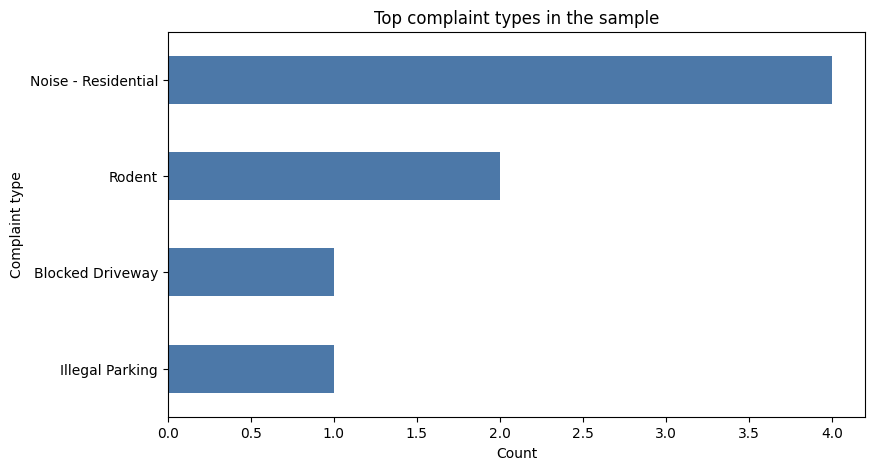

In [2]:
complaint_distribution = (
    records_df["complaint_type"]
    .value_counts()
    .rename_axis("complaint_type")
    .reset_index(name="count")
)

display(complaint_distribution.head(15))

plot_df = complaint_distribution.head(15).sort_values("count")
try:
    import matplotlib.pyplot as plt

    ax = plot_df.plot.barh(
        x="complaint_type",
        y="count",
        figsize=(9, 5),
        color="#4C78A8",
        legend=False,
        title="Top complaint types in the sample",
    )
    ax.set_xlabel("Count")
    ax.set_ylabel("Complaint type")
    plt.show()
except ImportError:
    display(plot_df)

,complaint_type,total_records,matched_records,other_records,coverage_rate,top_unmatched_descriptors
4,Noise - Residential,4,4,0,1.0,[]
6,Rodent,2,2,0,1.0,[]
1,Blocked Driveway,1,1,0,1.0,[]
3,Illegal Parking,1,1,0,1.0,[]
0,Abandoned Vehicle,0,0,0,0.0,[]
2,HEAT/HOT WATER,0,0,0,0.0,[]
5,Noise - Street/Sidewalk,0,0,0,0.0,[]
7,Street Condition,0,0,0,0.0,[]
8,UNSANITARY CONDITION,0,0,0,0.0,[]


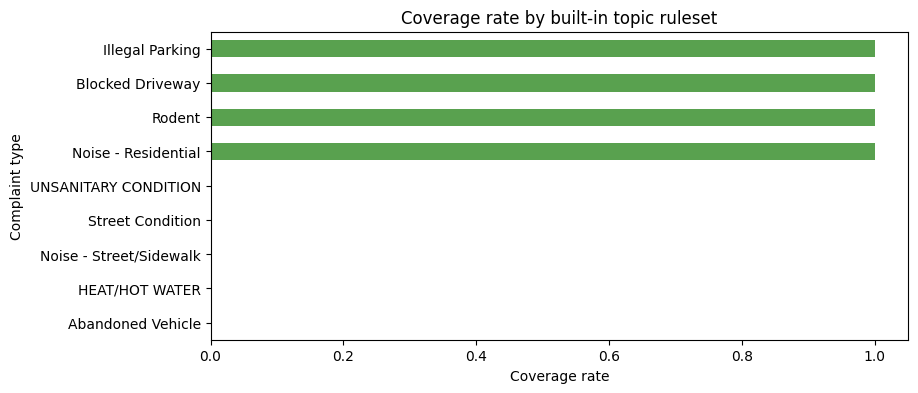

In [3]:
coverage_rows = []
for complaint_type in nyc311.supported_topic_queries():
    coverage = nyc311.analyze_topic_coverage(
        records,
        nyc311.TopicQuery(complaint_type=complaint_type, top_n=10),
    )
    coverage_rows.append(coverage)

coverage_df = nyc311.coverage_to_dataframe(coverage_rows).sort_values(
    ["coverage_rate", "total_records"],
    ascending=[False, False],
)
display(coverage_df)

plot_df = coverage_df.sort_values("coverage_rate")
try:
    import matplotlib.pyplot as plt

    ax = plot_df.plot.barh(
        x="complaint_type",
        y="coverage_rate",
        figsize=(9, 4),
        color="#59A14F",
        legend=False,
        title="Coverage rate by built-in topic ruleset",
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Coverage rate")
    ax.set_ylabel("Complaint type")
    plt.show()
except ImportError:
    display(plot_df[["complaint_type", "coverage_rate", "other_records"]])

## Auditing Rule Coverage

The built-in topic constants are intended to be data-driven starting points, not hidden magic.

If a ruleset falls back to `other`, inspect the unmatched descriptors directly so you can decide whether to:
- keep the descriptor in `other`
- add a better built-in rule
- supply custom rules in your own workflow

In [4]:
illegal_parking_coverage = nyc311.analyze_topic_coverage(
    records,
    nyc311.TopicQuery("Illegal Parking", top_n=10),
)

unmatched_df = nyc311.records_to_dataframe(
    [
        nyc311.ServiceRequestRecord(
            service_request_id=f"unmatched-{index}",
            created_date=date(2025, 1, 1),
            complaint_type="Illegal Parking",
            descriptor=descriptor,
            borough=nyc311.BOROUGH_BROOKLYN,
            community_district="01 BROOKLYN",
        )
        for index, (descriptor, _count) in enumerate(
            illegal_parking_coverage.top_unmatched_descriptors,
            start=1,
        )
    ]
)[["descriptor"]]
unmatched_df["count"] = [
    count for _descriptor, count in illegal_parking_coverage.top_unmatched_descriptors
]
display(unmatched_df)

,descriptor,count


In [5]:
custom_rules = (
    ("hydrant_issue", ("hydrant", "low water pressure")),
    ("leak", ("leak", "leaking")),
)

synthetic_records = [
    nyc311.ServiceRequestRecord(
        service_request_id="demo-1",
        created_date=date(2025, 1, 1),
        complaint_type="Water System",
        descriptor="Low water pressure near hydrant",
        borough=nyc311.BOROUGH_BROOKLYN,
        community_district="01 BROOKLYN",
    ),
    nyc311.ServiceRequestRecord(
        service_request_id="demo-2",
        created_date=date(2025, 1, 2),
        complaint_type="Water System",
        descriptor="Leaking hydrant on corner",
        borough=nyc311.BOROUGH_BROOKLYN,
        community_district="01 BROOKLYN",
    ),
    nyc311.ServiceRequestRecord(
        service_request_id="demo-3",
        created_date=date(2025, 1, 3),
        complaint_type="Water System",
        descriptor="Pressure issue in building basement",
        borough=nyc311.BOROUGH_BROOKLYN,
        community_district="01 BROOKLYN",
    ),
]

before_custom_rules = nyc311.analyze_topic_coverage(
    synthetic_records,
    nyc311.TopicQuery("Water System", top_n=10),
)
after_custom_rules = nyc311.analyze_topic_coverage(
    synthetic_records,
    nyc311.TopicQuery("Water System", top_n=10),
    custom_rules=custom_rules,
)

custom_coverage_df = nyc311.coverage_to_dataframe(
    [before_custom_rules, after_custom_rules]
)
custom_coverage_df.index = ["Fallback grouping", "Custom rules"]
display(custom_coverage_df)

,complaint_type,total_records,matched_records,other_records,coverage_rate,top_unmatched_descriptors
Fallback grouping,Water System,3,3,0,1.000000,[]
Custom rules,Water System,3,2,1,0.666667,"[(Pressure issue in building basement, 1)]"


,geography,geography_value,complaint_type,topic,complaint_count,geography_total_count,share_of_geography,topic_rank,is_dominant_topic
0,community_district,BROOKLYN 01,Noise - Residential,banging,1,2,0.5,1,True
1,community_district,BROOKLYN 01,Noise - Residential,party_music,1,2,0.5,2,False
2,community_district,BROOKLYN 03,Noise - Residential,construction,1,2,0.5,1,True
3,community_district,BROOKLYN 03,Noise - Residential,pet_noise,1,2,0.5,2,False


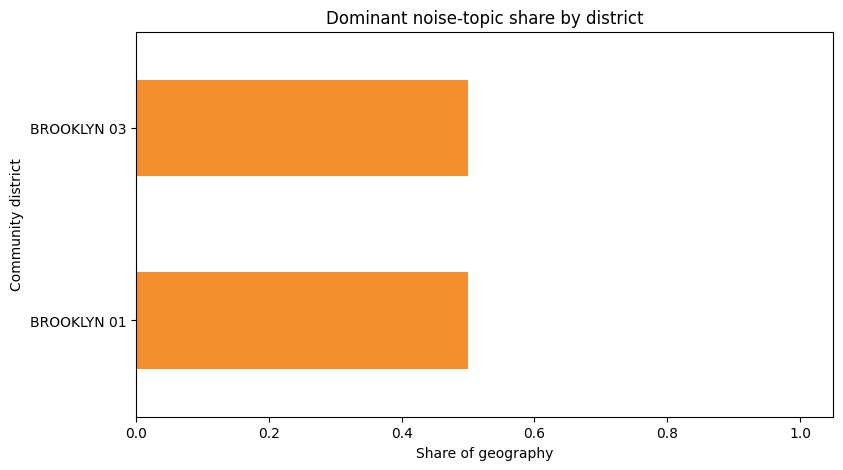

In [6]:
noise_assignments = nyc311.extract_topics(
    records,
    nyc311.TopicQuery("Noise - Residential", top_n=10),
)
noise_summaries = nyc311.aggregate_by_geography(
    noise_assignments,
    geography="community_district",
)
noise_summaries_df = nyc311.summaries_to_dataframe(noise_summaries)
display(noise_summaries_df.head(10))

dominant_noise_df = noise_summaries_df[
    noise_summaries_df["is_dominant_topic"]
].sort_values(
    "share_of_geography",
    ascending=False,
)
try:
    import matplotlib.pyplot as plt

    ax = (
        dominant_noise_df.head(12)
        .sort_values("share_of_geography")
        .plot.barh(
            x="geography_value",
            y="share_of_geography",
            figsize=(9, 5),
            color="#F28E2B",
            legend=False,
            title="Dominant noise-topic share by district",
        )
    )
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Share of geography")
    ax.set_ylabel("Community district")
    plt.show()
except ImportError:
    display(
        dominant_noise_df[["geography_value", "topic", "share_of_geography"]].head(12)
    )

/Users/blaise/Desktop/blaise-oss/nyc311/src/nyc311/analytics.py:94: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = zscore(values)


## Inline Audit Summary
- Complaint types audited: 9
- Best built-in coverage rate: 100.0%
- Noise anomaly flags above threshold: 0
- Resolution rows available: 4

,geography,geography_value,complaint_type,topic,complaint_count,geography_total_count,share_of_geography,topic_rank,z_score,is_anomaly,window_days,anomaly_threshold
0,community_district,BROOKLYN 01,Noise - Residential,banging,1,2,0.5,1,0.0,False,30,1.5
1,community_district,BROOKLYN 01,Noise - Residential,party_music,1,2,0.5,2,0.0,False,30,1.5
2,community_district,BROOKLYN 03,Noise - Residential,construction,1,2,0.5,1,0.0,False,30,1.5
3,community_district,BROOKLYN 03,Noise - Residential,pet_noise,1,2,0.5,2,0.0,False,30,1.5


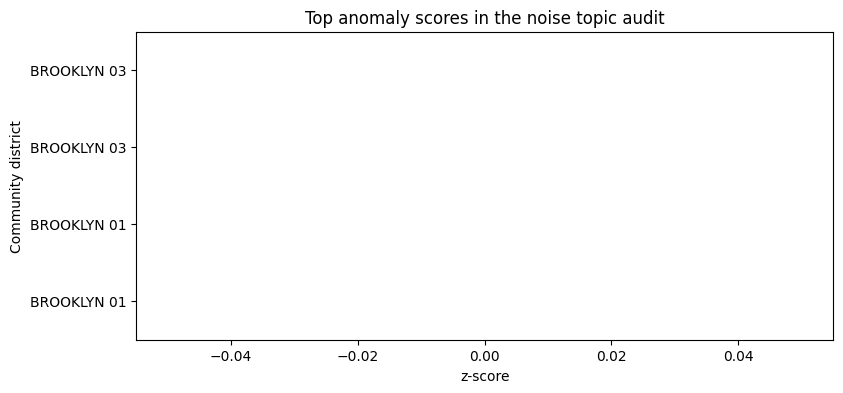

In [7]:
anomalies = nyc311.detect_anomalies(
    noise_summaries,
    nyc311.AnalysisWindow(days=30),
    z_threshold=1.5,
)
anomalies_df = nyc311.anomalies_to_dataframe(anomalies)

resolution_gaps = nyc311.analyze_resolution_gaps(
    records,
    [record for record in records if record.resolution_description is not None],
)
resolution_df = nyc311.gaps_to_dataframe(resolution_gaps)

display(
    Markdown(
        "\n".join(
            [
                "## Inline Audit Summary",
                f"- Complaint types audited: {coverage_df.shape[0]}",
                f"- Best built-in coverage rate: {coverage_df['coverage_rate'].max():.1%}",
                f"- Noise anomaly flags above threshold: {int(anomalies_df['is_anomaly'].sum())}",
                f"- Resolution rows available: {resolution_df.shape[0]}",
            ]
        )
    )
)

display(anomalies_df.head(10))

plot_df = anomalies_df.head(10).sort_values("z_score")
try:
    import matplotlib.pyplot as plt

    ax = plot_df.plot.barh(
        x="geography_value",
        y="z_score",
        figsize=(9, 4),
        color="#E15759",
        legend=False,
        title="Top anomaly scores in the noise topic audit",
    )
    ax.set_xlabel("z-score")
    ax.set_ylabel("Community district")
    plt.show()
except ImportError:
    display(plot_df[["geography_value", "topic", "z_score", "is_anomaly"]])